## HOMEWORK ASSIGNMENT 2

# Exercise 1, Markov Processes

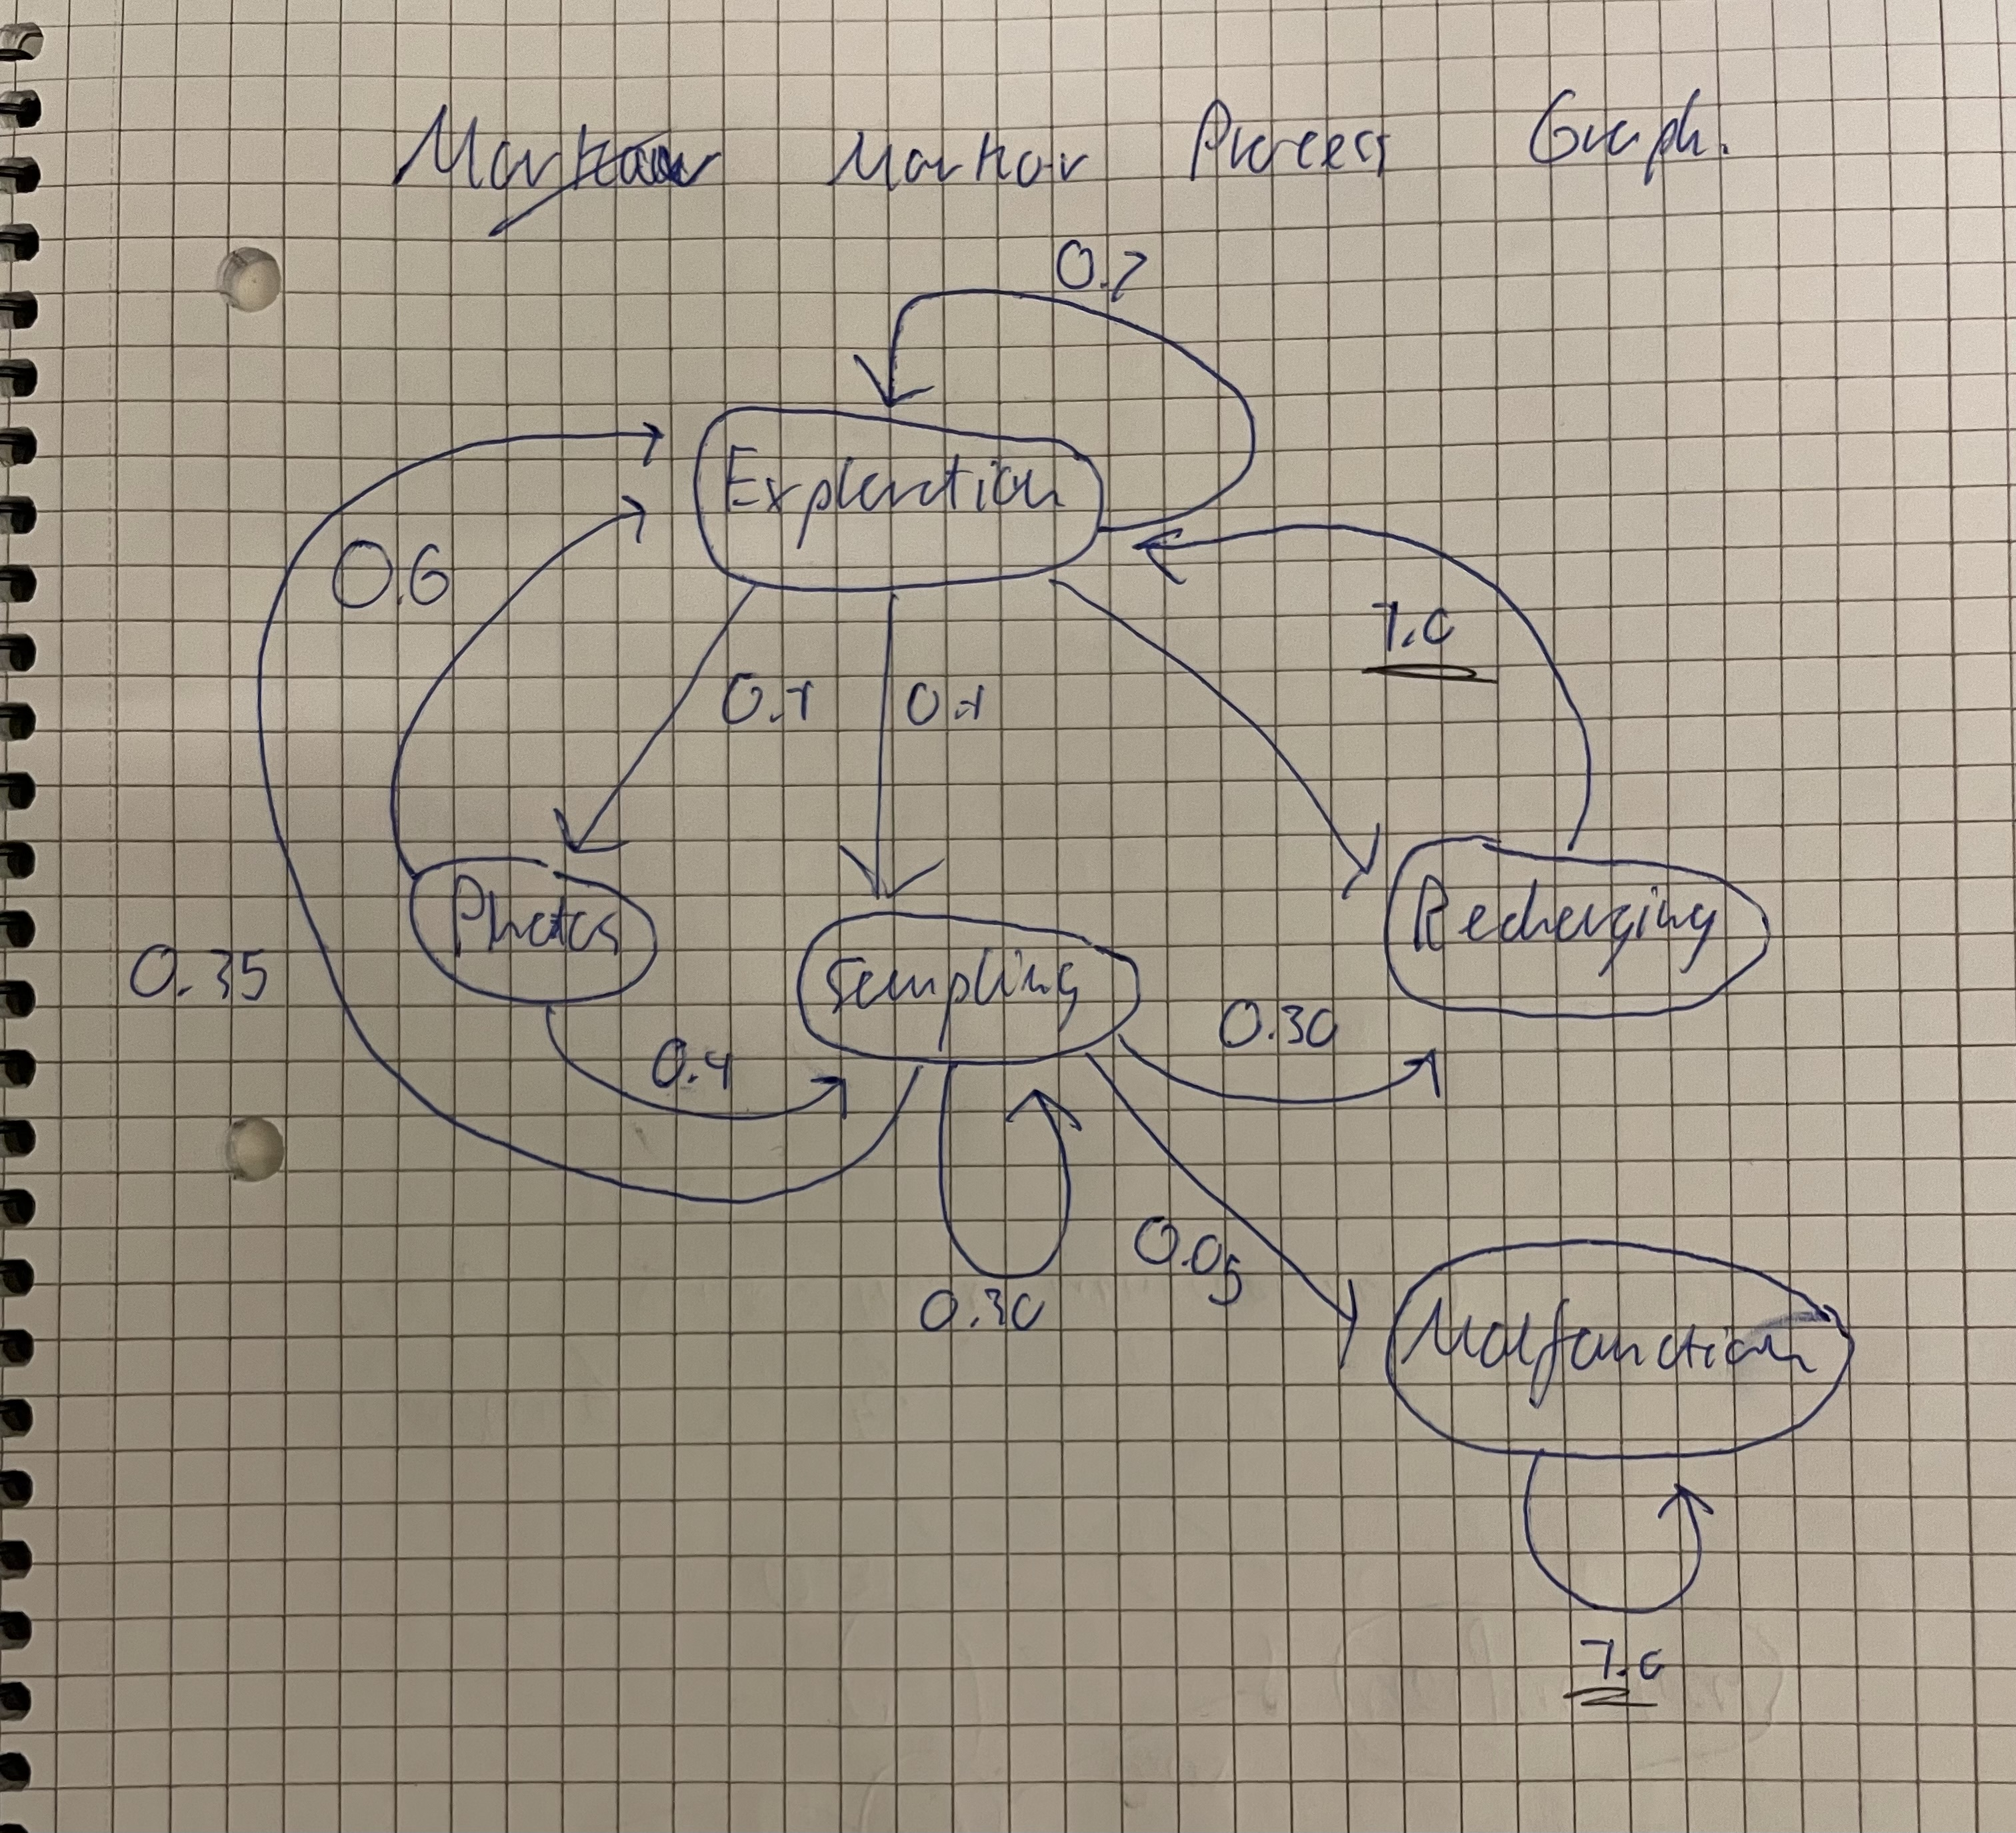

In [9]:
# Photo of possible states 
from IPython.display import Image, display
display(Image(r"..\..\photos\IMG_2854.jpg"))

1(). How the following model can comply with the assumptions of Markovianity: the assumptions of markovianity is simply that our model is defined such that the probability distribution of the next state is only dependent on the current state. The model we are presented with has the following quality, called the markov property, and therefore is compliant with markovian assumptions. Will also add a diagram showing the trainsition probabilities. 

2(). Drawing included above, formal definiton of a Markov Process is a tuple with states and transition probabilities. This will be shown underneath as a dictionary with states and their transition probabilities. Worth noting this is typically shown as a set of states and a transition matrix. 

In [10]:
markov_process = {
    "exploration": {
        "exploration": 0.7,
        "photos_of_sky": 0.1,
        "sampling": 0.1,
        "recharging": 0.1,
    },
    "photos_of_sky": {
        "exploration": 0.6,
        "sampling": 0.4,
    },
    "sampling": {
        "exploration": 0.35,
        "recharging": 0.30,
        "sampling": 0.30,
        "malfunction": 0.05,
    },
    "recharging": {
        "exploration": 1.0,
    },
    "malfunction": {
        "malfunction": 1.0,
    },
}


3(). All the states are not reachable from normal operative mode(exploration), take for example malfunction, which can only be reached from the state digging. 

4(). Say the robot starts in normal operative mode, if that means the state takes at least 10min to complete, then the earliest a malfunction can happen is in 20 mins, as it would take 2 state transitions(From Normal to sampling to malfunction), which also answers the question of prob in 20min = 1/10 *1/20 = 1/200, with p(malfunction in next 10) obviously being 0. For the last task, malfunction within 30min means there are multiple possible paths reaching malfunction within the time window. Therefore, the probability can be computed as: P(Malfunction in 20min) + P(malfunction in 30min) == 1/200 + all combos where you transition from sampling to malfunction in 30 min which yields: p(E-E-S) + P(E-P-S) + P(E-S-S) times p(S-M) which gives 7/10*1/10 + 1/10*4/10 + 1/10 * 3/10 = 7/100 + 4/100 + 3/100 =14/100 *1/20 = 1/200 + 14/2000 = 2.4/200 = 12/1000

5().If P(malfunction) increases depending on count(sampling), then the model could be both markovian and not markovian depending on how one handles the change. Introducing a state dependent counting parameter would allow all the needed information to be encoded into state S, which would preserve markovianity. 

6(). Tic-Tac-Toe as an MP? 
Doesnt feel super intiuitive but codex proposed states as board configs? which seems reasonable, 

7.(), obv that num states goes unreasonably high, would think for a standard 3x3 board, that one would reach 3^9 - the infeasible configs. This obv. implies scalabilty issues 

# Exercise 2, Markov Reward Processes

Expanding the drawn figure to include rewards: 

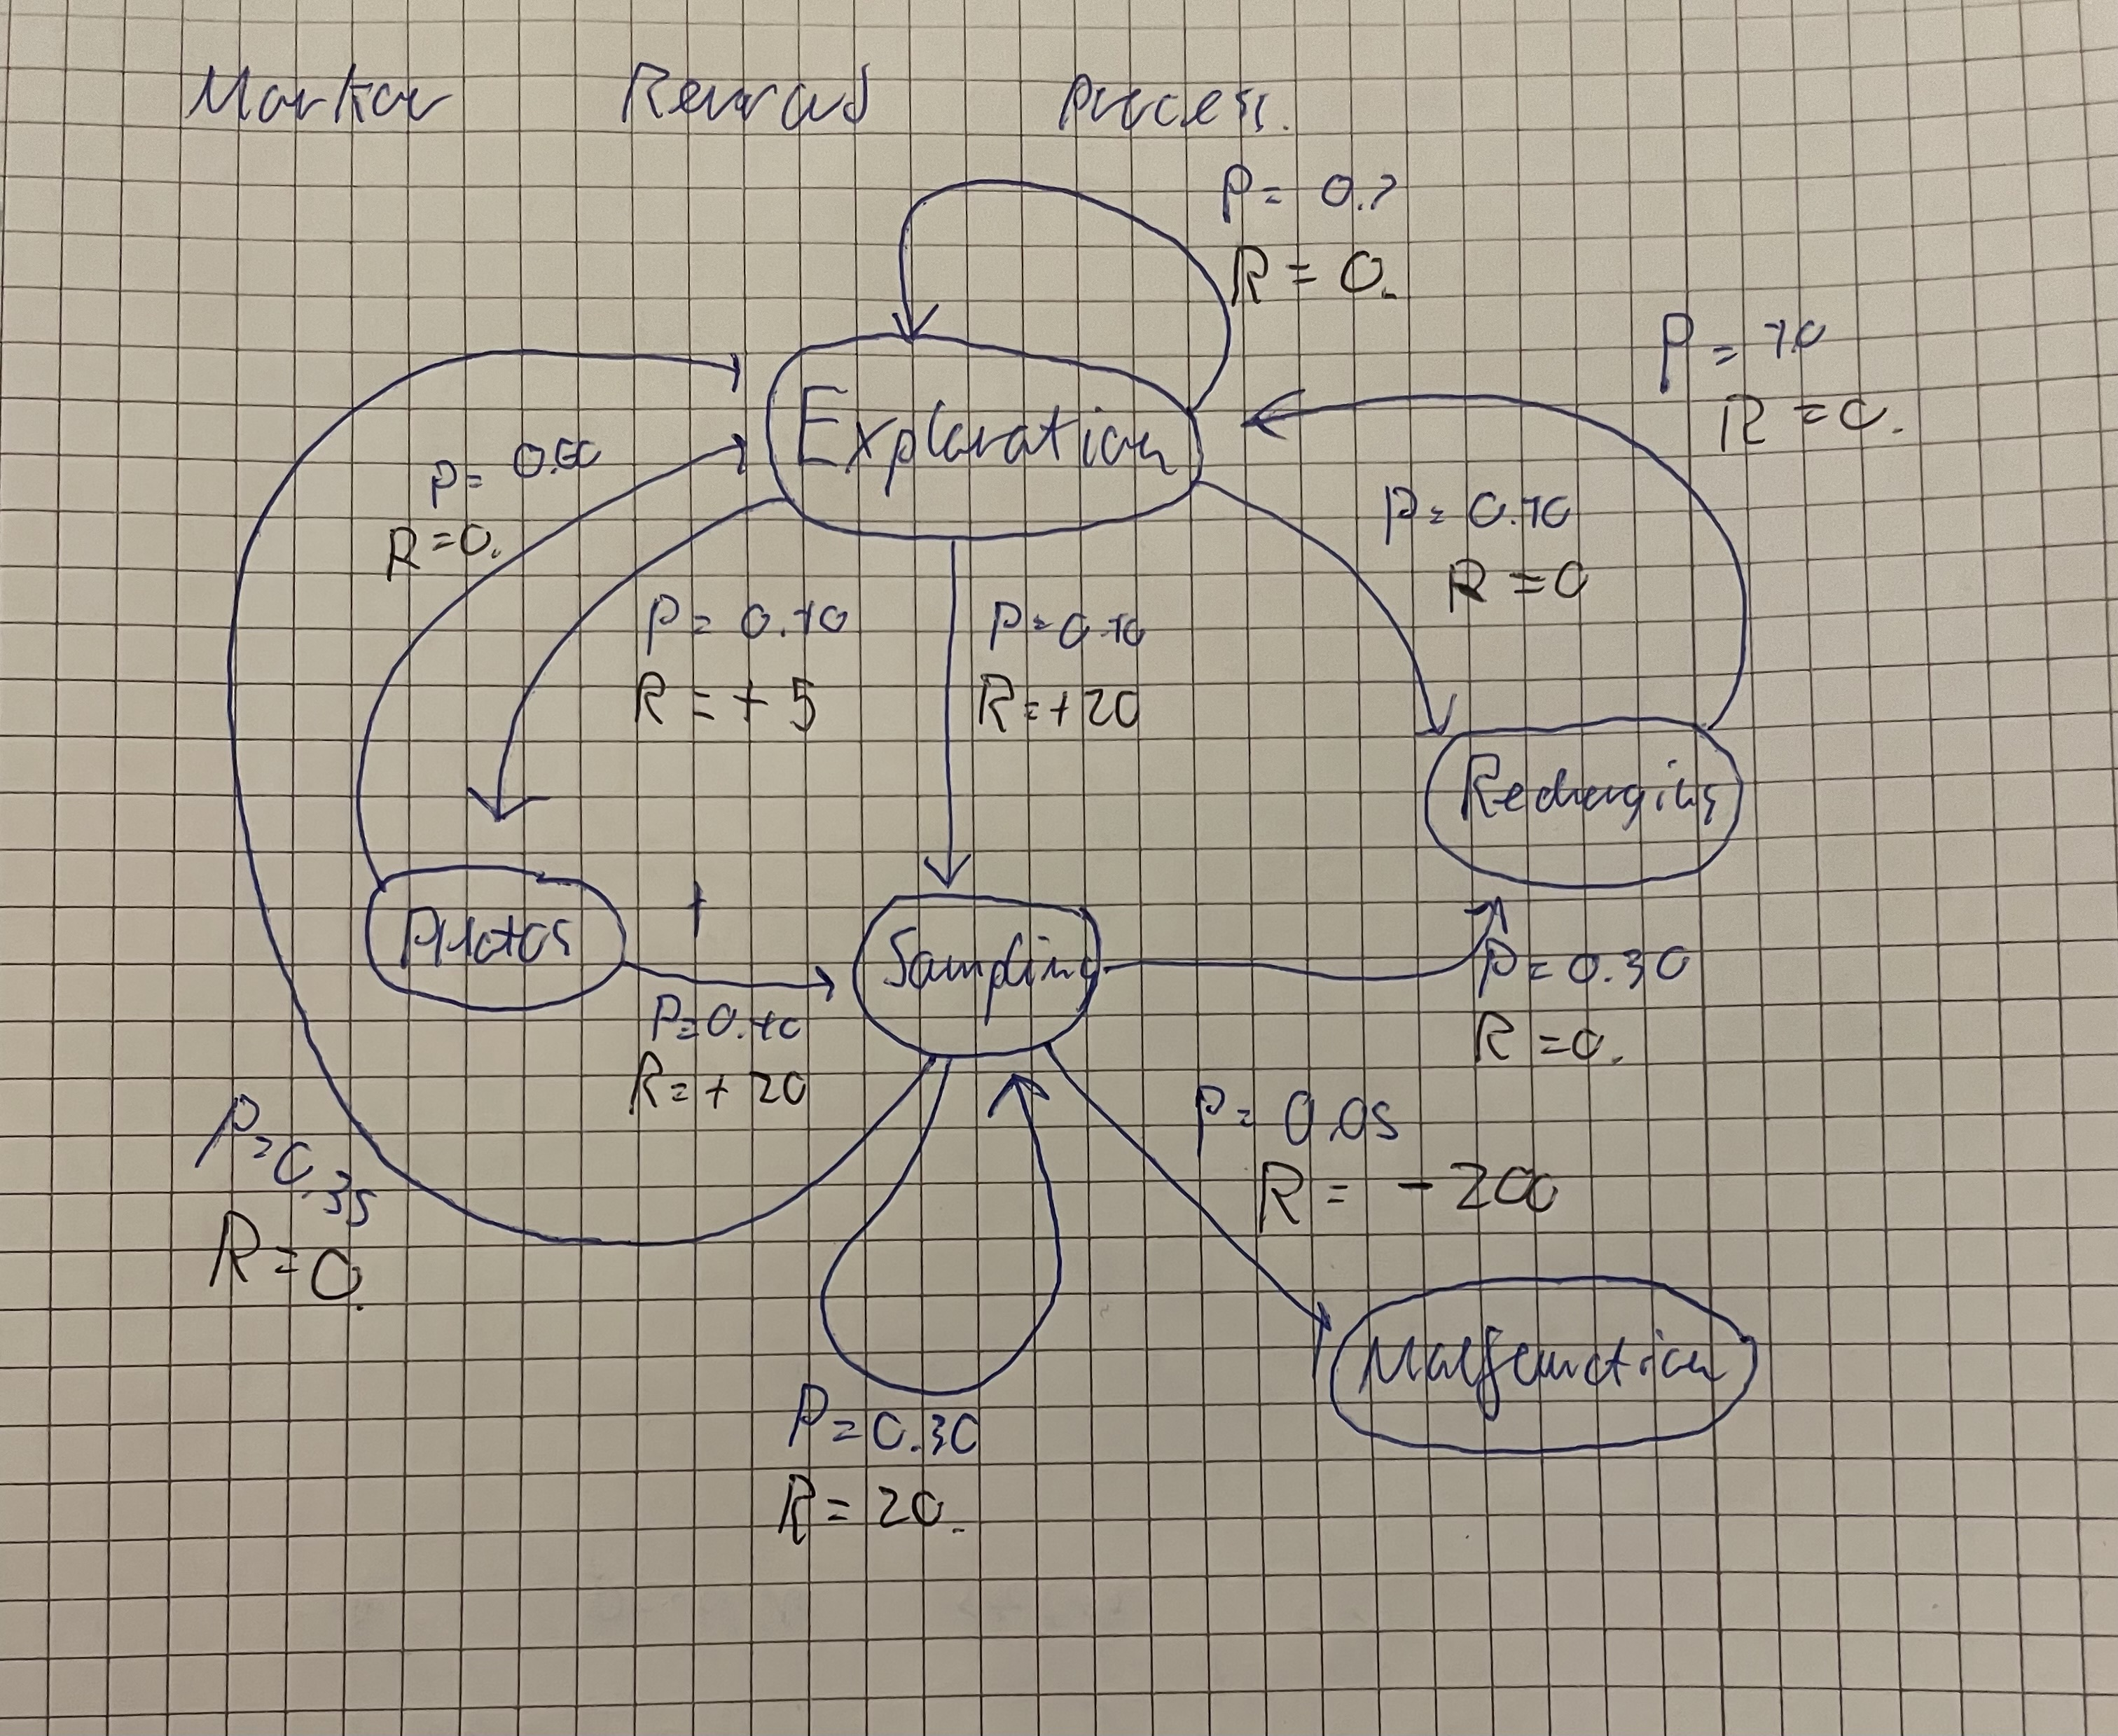

In [11]:
display(Image(r"..\..\photos\IMG_2857.jpg"))

2(). Reward next 10, P(R<0) in 20min? we need the discrete calculation of Ev, which is \sum R(s)_i * p(s)_i for i from 0 to n, which yields 0.7*0 + 0.1*5 + 0.1*20 + 0.1*0 giving Expected Reward = 2.5 (next 20min). Prob negative reward simply equal to prob malfunction = 1/200

# Exercise 3, markov Descicion Processes

1(). Mars Rover as a Markov Desicion Process?: 
would need

- States, Actions, Transition probability, Rewards, Discount factor. 

short answer, simply keep the last model as a base, but now introduce an action set to each state. This implies that the transition probabilities now depend on both state and action, and we will also need to specify the reward function s.t. its dependent on the action chosen aswell. Lastly, we need a policy: policy(action | state) which tells the agent what to do. (Formalize by expressing this mathematically?)

2.() obj: max rewards, min prob failure, with the transition probablilities in the MRP, one would expect the optimal policy to be the same as one risks failure for all selections which yield reward. (cannot farm reward with zero risk infinitely). Answer would also depend on time horion as there is now incentive to skip photos and just sample. 

3(). The first problem in ex. 8 hw1 was to implement algorithms to solve multi_armed_bandits_env1, so i am assuming i am tasked to transform the MABenv_1() into a MDP. The way to formalize MAB_env1() into a MDP is to assume a single state, as we are always in the same environment. From there, we define the action set as pulling each arm, with transition probabilities being 1 for all actions. Finally, the reward for each arm is the same as in the MAB_env. 

4(). Interesting RL problem not captured by MDP's? Rocket League?


# Exercise 4, Bellman Equations

1(). Defining Bellman equations for a Markov Process: i would think intuitively that it makes no sense, as a markov process does not have a reward as a parameter in the model, and as the whole point of the equations is to estimate the value of a state or action(with respect to its expected return(sum rewards with a discount for future rewards)), wwhile a markov process simply describes the states and prob of transitioning to next state. 

2(). Defining Bellman expectation equations for a MRP? 
The Bellman expectation eq. for an MDP is 
$$
v^{\pi}(s)
=\sum_{a\in\mathcal{A}} \pi(a\mid s)
\sum_{s'\in\mathcal{S}} P(s'\mid s,a)\Bigl(R(s,a,s')+\gamma v^{\pi}(s')\Bigr).
$$
which reduces to: 
$$
v(s)=R(s)+\gamma\sum_{s'\in\mathcal{S}}P(s'\mid s)\,v(s').
$$

for an MRP

3() bellman optimality equations for an MRP? no, as there are no actions in an MRP. 

4() derivation action value bellman expectation on paper, not here sadly 

5() state-value bellman exp in matrix form: V_pi(S) = r +gamma*Pv (for an MRP)

6() matrix notation usefull for large computation? captures order of operations? "makes the whole problem a linear system, can analyze and solve with linear algebra". 

# Exercise 5, Optimality

1() The value V_pi(S) is both policy and model-dependent, so obv not absolute/indep. 


2() an optimal policy is not always deterministic. Many settings where stochasticity is needed.

3() determinism implies that the agent wont explore, meaning learning can get stuck. => Learning needs randomness, want to find the best action before being greedy. 

4() optimal policy doesnt ensure best return on every run, but instead the point is that with an optimal policy, the avg. return on each run is the highest possible. In other words, an optimal policy means having the highest expected return given your current information

# part2, code related q's

# Exercise 6, dynamic programming

expressing the mountain q formally as an MDP: 

the set of states in this case is simply our coordinates in the mountain.  
the set of actions is our possible directions we can move in (upward, forward, downforward in this case as we are staring in the top left corner(grid def))
the reward as some function of the roughness of each tile and future tile
transition matrix being deterministic with some limit for boundry handling
some discount factor \gamma for future rewards 



2(), policy pi_{str} which is simply heading straight ahead, and use policy eval to compute V_{str}

In [12]:
import sys 
import numpy as np
sys.path.insert(0, '../../src')
from mountain import Mountain_one

adad c:\pythonlek\8sem\Reinforcement-Learning-\notebooks\homework2\../../src


In [13]:
terrain = Mountain_one()
Heigth, Width = terrain.get_map().shape

def eval_pi_str(env, gamma=1.0, theta=1e-10, max_iter=10_000, right_to_left=True):
    Value = np.zeros((Heigth, Width), dtype=float)   #simply init all values as zero

    for _ in range(max_iter):  # _ here is simply to denote that the variable wont be used 
        delta = 0.0
        cols = range(Width-1, -1, -1) if right_to_left else range(Width)

        for j in cols:                          #need to simulate the values for all starting pos: to get all the paths 
            for i in range(Heigth):
                state = (i, j)
                old = Value[i, j]   # V[i, j] here is state value , equiv to V_{pi}(s) 

                action = "forward"                    # pi_str
                s_next = env.next_state(state, action)
                reward = env.get_reward(state, action)

                Value[i, j] = reward + gamma * Value[s_next]  # iteratively updating the value
                delta = max(delta, abs(old - Value[i, j]))

        if delta < theta:
            break

    return Value

V_str = eval_pi_str(terrain, gamma=1.0, right_to_left=True)
print("V_str shape:", V_str.shape)
print(V_str)


V_str shape: (31, 100)
[[-67.43137399 -66.64706019 -65.85098175 ...  -0.79607844   0.
    0.        ]
 [-61.6588255  -60.88627647 -60.09411957 ...  -0.79607844   0.
    0.        ]
 [-56.38431562 -55.62745286 -54.83921756 ...  -0.7254902    0.
    0.        ]
 ...
 [-45.56470706 -45.00784426 -44.50588346 ...  -0.890196     0.
    0.        ]
 [-54.09804134 -53.51372759 -52.94902169 ...  -0.882353     0.
    0.        ]
 [-60.38431538 -59.80000163 -59.19608003 ...  -0.87058824   0.
    0.        ]]


comment to task2, gamma(discount factor) set equal to 1 here instead of f.ex. 0.9 as we dont want to discount time(roughness index) of a tile in the future, as we only worry about total time spent here to get down. 

Ex 3(). comparing righ_to_left and left_to_right ;) 

In [14]:
V_str_ltr = eval_pi_str(terrain, gamma = 1.0, right_to_left=False)
print("V_str_ltr shape:", V_str.shape)

V_str_ltr shape: (31, 100)


the results, in this case the estimated state value when following the policy of going forwad(0,1) is the same both when traversing from right to left and left to right. I would, however, expect a difference in the number of iterations needed for convergence.

4(). follow-up to the q. above probably, one gets the same result for our estimated value function, however the speed for convergence in estimate would likely be different. 

5, 6, plotting trajectories followed by the robot.

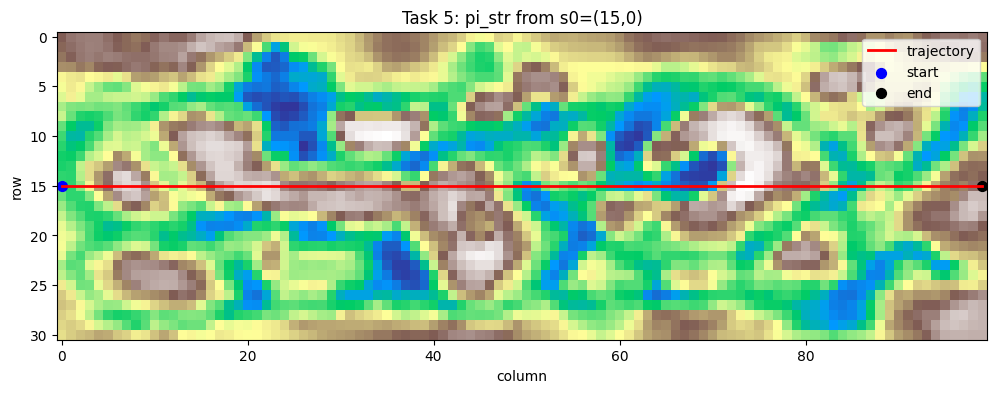

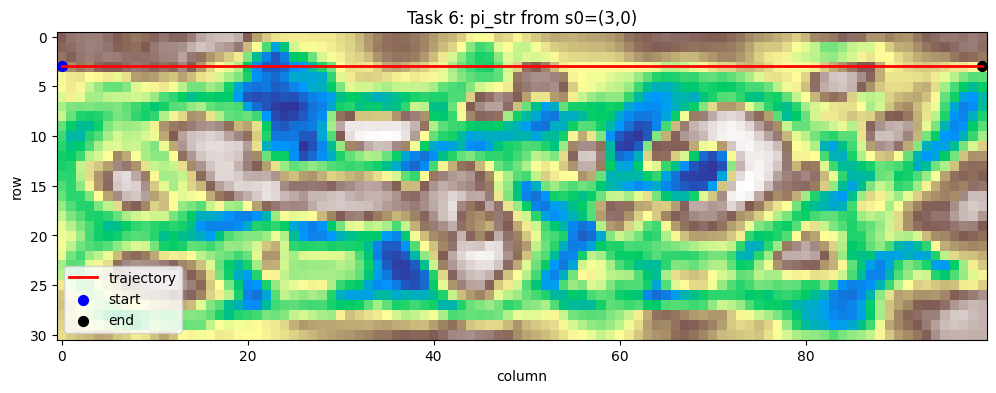

In [15]:
import matplotlib.pyplot as plt 

import matplotlib.pyplot as plt
import numpy as np

# pi_str: always go straight forward
def pi_str(state):
    return "forward"

def rollout_trajectory(env, start_state, policy):
    trajectory = [start_state]
    state = start_state

    # stop when we reach last column
    while state[1] < 99:
        action = policy(state)
        state = env.next_state(state, action)
        trajectory.append(state)

    return trajectory

def plot_trajectory(env, trajectory, title):
    hill = env.get_map()

    plt.figure(figsize=(12, 4))
    plt.imshow(hill, cmap="terrain", origin="upper", aspect="auto") # imshow with hill as param to make "heatmap"
    rows = [s[0] for s in trajectory]
    cols = [s[1] for s in trajectory]
    plt.plot(cols, rows, color="red", linewidth=2, label="trajectory")
    plt.scatter(cols[0], rows[0], color="blue", s=50, label="start")
    plt.scatter(cols[-1], rows[-1], color="black", s=50, label="end")
    plt.title(title)
    plt.xlabel("column")
    plt.ylabel("row")
    plt.legend()
    plt.show()

# Task 5: s0 = (15, 0)
traj_15 = rollout_trajectory(terrain, (15, 0), pi_str)
plot_trajectory(terrain, traj_15, "Task 5: pi_str from s0=(15,0)")

# Task 6: s0 = (3, 0)
traj_3 = rollout_trajectory(terrain, (3, 0), pi_str)
plot_trajectory(terrain, traj_3, "Task 6: pi_str from s0=(3,0)")


Exercise 7, optimal starting position with the straight-forward trajectory? 

In [16]:
best_row = np.argmax(V_str[:, 0])
best_value = V_str[best_row, 0]
print(best_row, best_value)


7 -35.72156986299999


The Idea here is that we have already estimated the value of all states under the policy_str, so we can simply return the sum along the row with the lowest total score, as that would be the optimal strategy for policy_str

8, random action policy



In [17]:
import math
terrain = Mountain_one()
Heigth, Width = terrain.get_map().shape


terrain = Mountain_one()
Heigth, Width = terrain.get_map().shape

def eval_pi_rnd(env, gamma=1.0, theta=1e-10, max_iter=10_000, right_to_left=True):
    Value = np.zeros((Heigth, Width), dtype=float)   #simply init all values as zero
    actions = env.actions
    action_prob = 1/len(actions)

    for _ in range(max_iter):  # _ here is simply to denote that the variable wont be used 
        delta = 0.0
        cols = range(Width-1, -1, -1) if right_to_left else range(Width)

        for j in cols:
            for i in range(Heigth):
                state = (i, j)
                old = Value[i, j]   # V[i, j] here is state value , equiv to V_{pi}(s) 

                expected_value = 0      # what differs now is that the stocastic part of the bellman exp. needs to be introduced, 
                for action in actions:              # which one remembers were not needed with deterministic action :) 
                    state_next = env.next_state(state, action)
                    reward = env.get_reward(state, action)
                    expected_value += action_prob * (reward + gamma*Value[state_next])

                Value[i, j] = expected_value
                delta = max(delta, abs(old - Value[i, j]))


        if delta < theta:
            break

    return Value

V_rnd = eval_pi_rnd(terrain, gamma=1.0, right_to_left=True)
print("V_rnd shape:", V_rnd.shape)
print(V_rnd)


V_rnd shape: (31, 100)
[[-54.30150797 -53.66434371 -53.00697767 ...  -0.79607844   0.
    0.        ]
 [-53.85540821 -53.23465986 -52.59476199 ...  -0.77254903   0.
    0.        ]
 [-52.95902348 -52.35349547 -51.72576927 ...  -0.68104577   0.
    0.        ]
 ...
 [-46.89498289 -46.27210972 -45.67359897 ...  -0.8862745    0.
    0.        ]
 [-46.88228161 -46.28460736 -45.69790631 ...  -0.88104575   0.
    0.        ]
 [-46.92227451 -46.36463746 -45.81172849 ...  -0.87450983   0.
    0.        ]]


9, plotting one sample traj from following random action policy

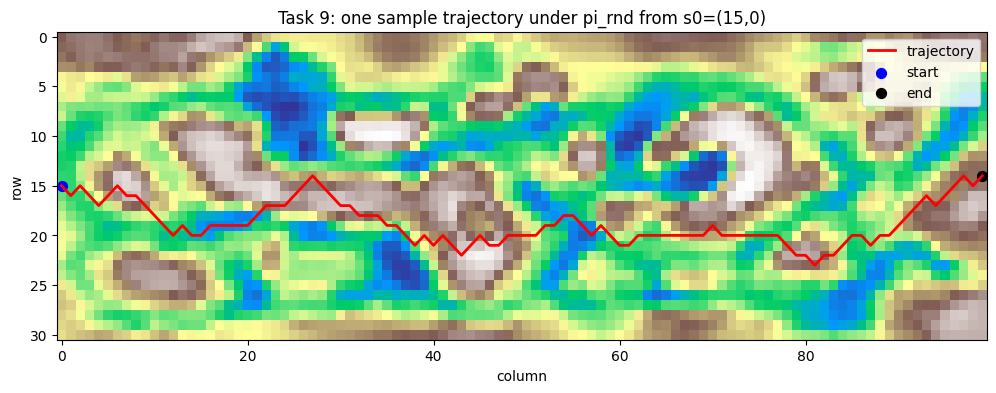

num steps: 99
first 15 actions: [np.str_('downforward'), np.str_('upforward'), np.str_('downforward'), np.str_('downforward'), np.str_('upforward'), np.str_('upforward'), np.str_('downforward'), np.str_('forward'), np.str_('downforward'), np.str_('downforward'), np.str_('downforward'), np.str_('downforward'), np.str_('upforward'), np.str_('downforward'), np.str_('forward')]


In [18]:
def pi_rnd(state, env):
    return np.random.choice(env.actions)  # uniform

def rollout_random_trajectory(env, start_state, seed=None):
    if seed is not None:
        np.random.seed(seed)

    trajectory = [start_state]
    actions_taken = []
    state = start_state

    while state[1] < 99:  # until rightmost column
        action = pi_rnd(state, env)
        next_state = env.next_state(state, action)

        actions_taken.append(action)
        trajectory.append(next_state)
        state = next_state

    return trajectory, actions_taken

def plot_trajectory(env, trajectory, title):
    hill = env.get_map()
    rows = [s[0] for s in trajectory]
    cols = [s[1] for s in trajectory]

    plt.figure(figsize=(12, 4))
    plt.imshow(hill, cmap="terrain", origin="upper", aspect="auto")
    plt.plot(cols, rows, color="red", linewidth=2, label="trajectory")
    plt.scatter(cols[0], rows[0], color="blue", s=50, label="start")
    plt.scatter(cols[-1], rows[-1], color="black", s=50, label="end")
    plt.title(title)
    plt.xlabel("column")
    plt.ylabel("row")
    plt.legend()
    plt.show()

# Task 9
traj_rnd, acts_rnd = rollout_random_trajectory(terrain, (15, 0), seed=42)
plot_trajectory(terrain, traj_rnd, "Task 9: one sample trajectory under pi_rnd from s0=(15,0)")
print("num steps:", len(acts_rnd))
print("first 15 actions:", acts_rnd[:15])


10, 11. Learnt something different? got to see how stochastisity affects the estimated values for some of the possible states 

In [19]:
print(V_rnd[15, 0], V_str[15, 0])
print(V_str[3, 0])

""" to 11, going randomly from (15, 0) as init yielded better results than the straight-forward policy for both (15, 0) and (3, 0) as
initial positions """ 


-51.30835471835944 -57.80784459
-52.796080069999995


' to 11, going randomly from (15, 0) as init yielded better results than the straight-forward policy for both (15, 0) and (3, 0) as\ninitial positions '

12() issue of exploration affecting the final result?

Not entirely sure how to interpret this, as one strategy is not exploring at all whilst the others does a lot of exploration, but both results are in some way affected by exploration(or the lack of)

13, finding an optimal policy using std. iteraion + 14, plotting opt. trajectory for both starting pos. 

Optimal value at (15,0): -22.435294938
Optimal value at (3,0): -22.537255807999998
Best starting row: 9, value: -21.670589087999993


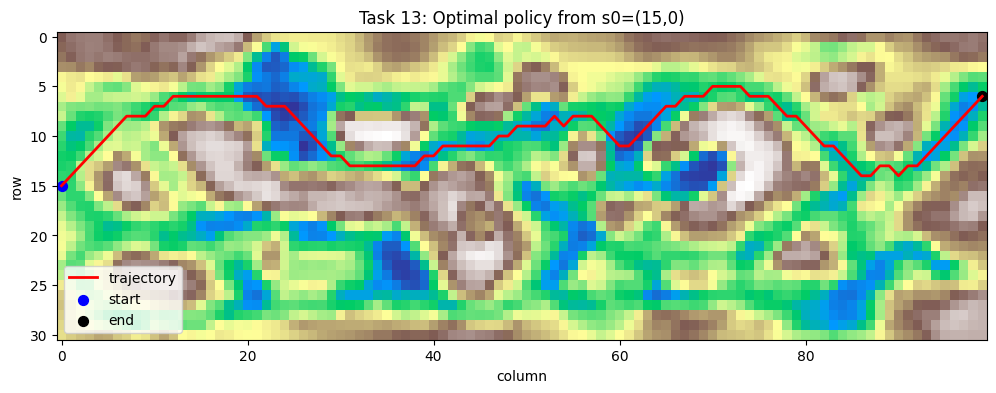

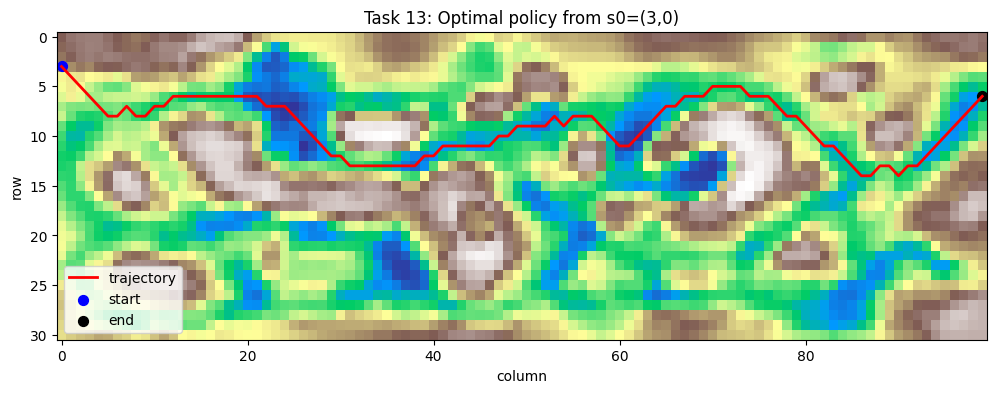

In [20]:
def policy_evaluation(env, policy, gamma=1.0, theta=1e-10, max_iter=10_000):
    #init all state values as zero 
    Value = np.zeros((Heigth, Width), dtype=float)

    for _ in range(max_iter):
        delta = 0.0

        for j in range(Width):
            for i in range(Heigth):
                state = (i, j)
                old = Value[i, j]

                action = policy(state)
                next_state = env.next_state(state, action)
                reward = env.get_reward(state, action)

                Value[i, j] = reward + gamma * Value[next_state]
                delta = max(delta, abs(old - Value[i, j]))

        if delta < theta:
            break

    return Value 

def policy_improvement(env, Value, gamma=1.0):
    def improved_policy(state):
        best_action = None
        best_value = -math.inf

        for action in env.actions:
            next_state = env.next_state(state, action)
            reward = env.get_reward(state, action)
            action_value = reward + gamma * Value[next_state]

            if action_value > best_value:
                best_value = action_value
                best_action = action

        return best_action

    return improved_policy


def standard_policy_iteration(env, gamma=1.0, theta=1e-10, max_iter=10_000):
    # start with a random policy
    def random_policy(state):
        return np.random.choice(env.actions)

    policy = random_policy

    for _ in range(max_iter):
        Value = policy_evaluation(env, policy, gamma, theta)
        new_policy = policy_improvement(env, Value, gamma)

        # check for convergence
        if all(new_policy((i, j)) == policy((i, j)) for i in range(Heigth) for j in range(Width)):
            break

        policy = new_policy

    return policy, Value

# all models defined above, 
np.random.seed(42)
optimal_policy, V_opt = standard_policy_iteration(terrain, gamma=1.0, theta=1e-10)

print("Optimal value at (15,0):", V_opt[15, 0])
print("Optimal value at (3,0):", V_opt[3, 0])

best_row = np.argmax(V_opt[:, 0])
print(f"Best starting row: {best_row}, value: {V_opt[best_row, 0]}")

# plot optimal trajectory from (15, 0)
traj_opt = rollout_trajectory(terrain, (15, 0), optimal_policy)
plot_trajectory(terrain, traj_opt, "Task 13: Optimal policy from s0=(15,0)")

# plot optimal trajectory from (3, 0)
traj_opt_3 = rollout_trajectory(terrain, (3, 0), optimal_policy)
plot_trajectory(terrain, traj_opt_3, "Task 13: Optimal policy from s0=(3,0)")

15, now truncated policy iteration


In [24]:
"""Reusing already implemented functions to compute truncated policy iteration algo"""

def truncated_policy_evaluation(env, policy, Value, gamma=1.0, eval_steps=5):
    """Run exactly eval_steps sweeps — no convergence check."""
    for _ in range(eval_steps):
        for j in range(Width):
            for i in range(Heigth):
                state = (i, j)
                action = policy(state)
                next_state = env.next_state(state, action)
                reward = env.get_reward(state, action)
                Value[i, j] = reward + gamma * Value[next_state]
    return Value


def truncated_policy_iteration(env, gamma=1.0, max_iter=10_000, eval_steps=5):
    def random_policy(state):
        return np.random.choice(env.actions)

    policy = random_policy
    Value = np.zeros((Heigth, Width), dtype=float)

    for _ in range(max_iter):
        Value = truncated_policy_evaluation(env, policy, Value, gamma, eval_steps)
        new_policy = policy_improvement(env, Value, gamma)

        if all(new_policy((i, j)) == policy((i, j)) for i in range(Heigth) for j in range(Width)):
            break

        policy = new_policy

    return policy, Value

np.random.seed(42)
truncated_policy, V_truncated = truncated_policy_iteration(terrain, gamma=1.0, max_iter=10_000, eval_steps=5)   
print("Truncated Optimal value at (15,0):", V_truncated[15, 0])     
print("Truncated Optimal value at (3,0):", V_truncated[3, 0])
best_row_truncated = np.argmax(V_truncated[:, 0])
print(f"Truncated Best starting row: {best_row_truncated}, value: {V_truncated[best_row_truncated, 0]}")


Truncated Optimal value at (15,0): -3.7882354599999997
Truncated Optimal value at (3,0): -4.24313742
Truncated Best starting row: 9, value: -3.3333334399999996


Task 16, plotting the results from truncated policy iteration 

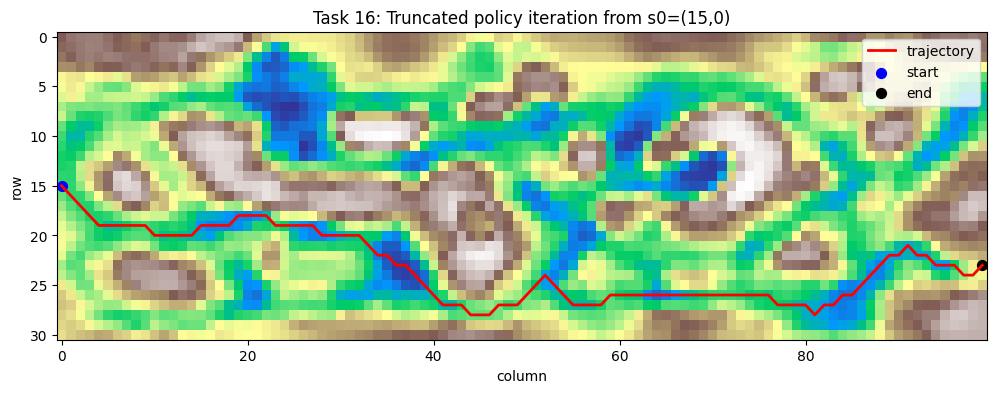

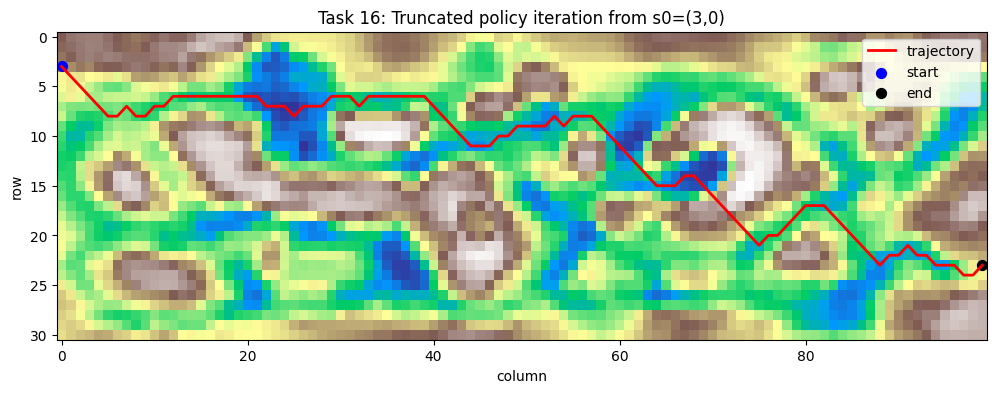

In [29]:
#plotting the optimal trajectory from (15, 0) using truncated policy iteration
traj_truncated_opt = rollout_trajectory(terrain, (15, 0), truncated_policy)
plot_trajectory(terrain, traj_truncated_opt, "Task 16: Truncated policy iteration from s0=(15,0)")

traj_truncated_opt = rollout_trajectory(terrain, (3, 0), truncated_policy) 
plot_trajectory(terrain, traj_truncated_opt, "Task 16: Truncated policy iteration from s0=(3,0)")   

17, value iteration to find optimal policy + 18, plotting the results 

k=1 TPI (full eval) V(15,0): -23.721569354999993


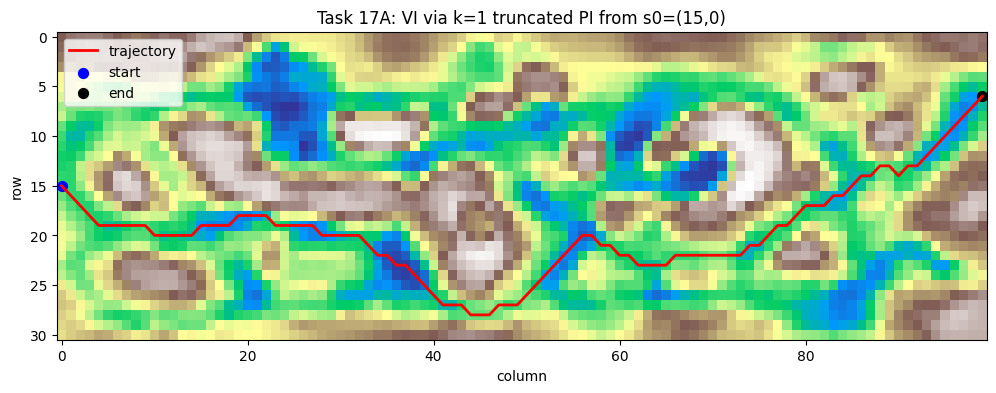

Direct VI V(15,0): -22.435294938


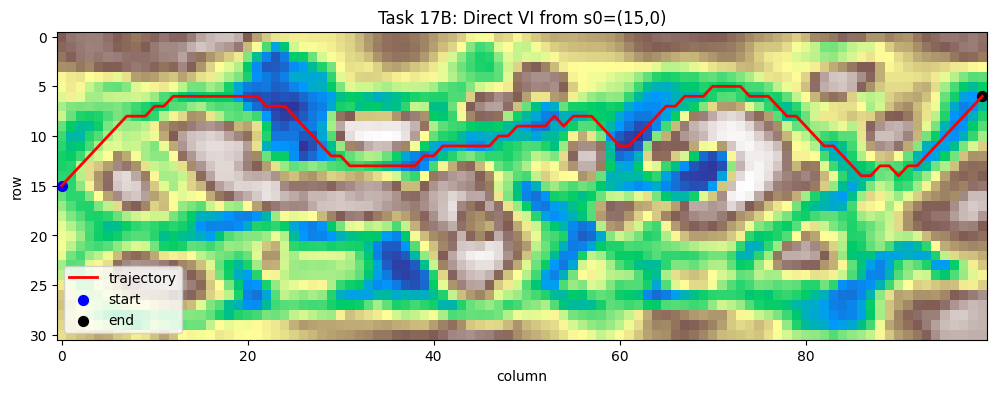

k=1 TPI policy == direct VI policy: False


In [31]:
# ...existing code...

# --- 17A) Value Iteration as k=1 Truncated Policy Iteration ---
np.random.seed(42)  # start from π_rnd
vi_k1_policy, V_vi_k1_partial = truncated_policy_iteration(
    terrain, gamma=1.0, max_iter=10_000, eval_steps=1
)

# optional: fully evaluate the final policy for comparable values
V_vi_k1 = policy_evaluation(terrain, vi_k1_policy, gamma=1.0, theta=1e-10)

print("k=1 TPI (full eval) V(15,0):", V_vi_k1[15, 0])

traj_k1 = rollout_trajectory(terrain, (15, 0), vi_k1_policy)
plot_trajectory(terrain, traj_k1, "Task 17A: VI via k=1 truncated PI from s0=(15,0)")


# --- 17B) Direct Value Iteration (Bellman optimality equation) ---
def value_iteration_direct(env, gamma=1.0, theta=1e-10, max_iter=10_000):
    Value = np.zeros((Heigth, Width), dtype=float)

    for _ in range(max_iter):
        delta = 0.0
        for j in range(Width):
            for i in range(Heigth):
                state = (i, j)
                old = Value[i, j]

                best = -math.inf
                for action in env.actions:
                    next_state = env.next_state(state, action)
                    reward = env.get_reward(state, action)
                    q = reward + gamma * Value[next_state]
                    if q > best:
                        best = q

                Value[i, j] = best
                delta = max(delta, abs(old - Value[i, j]))

        if delta < theta:
            break

    return Value

V_vi_direct = value_iteration_direct(terrain, gamma=1.0, theta=1e-10)
vi_direct_policy = policy_improvement(terrain, V_vi_direct, gamma=1.0)

print("Direct VI V(15,0):", V_vi_direct[15, 0])

traj_direct = rollout_trajectory(terrain, (15, 0), vi_direct_policy)
plot_trajectory(terrain, traj_direct, "Task 17B: Direct VI from s0=(15,0)")

# Optional sanity check:
same_actions = all(
    vi_k1_policy((i, j)) == vi_direct_policy((i, j))
    for i in range(Heigth) for j in range(Width)
)
print("k=1 TPI policy == direct VI policy:", same_actions)

task 19, 20 

Not identical, as the "more efficient algos" will underestimate state values which also affects the optimal policy in state s as the policys are state-dependent. This is why we see different paths in the different plots. 

For the efficiency question, i would say that the most efficient solution for policy iteration was the one that ran the quickest, which was value iteration. (simply, special case of truncated policy iteration with k = 1, instead of f.eks. 5.)
for the policy eval the state sorting was mostly left to right. 